# 220. Contains Duplicate III
https://leetcode.com/problems/contains-duplicate-iii/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Bucket sort | $O(n)$ | $O(k)$ | Optimal — bucket width = valueDiff+1 |
| Sorted set (BST) | $O(n \log k)$ | $O(k)$ | Use TreeSet/SortedList |
| Brute force | $O(n \cdot k)$ | $O(1)$ | Check each window |

## Methodology

Use bucket sort with bucket width `w = valueDiff + 1`. Map each value to bucket `value / w` (handling negatives). If two values share a bucket, their difference is at most valueDiff. Also check adjacent buckets. Maintain a sliding window of size indexDiff by removing old buckets. This gives O(n) time and O(k) space.

## Solutions

### C#

In [ ]:
public class Solution {
    public bool ContainsNearbyAlmostDuplicate(int[] nums, int indexDiff, int valueDiff) {
        if (valueDiff < 0) return false;
        var buckets = new Dictionary<long, long>();
        long w = (long)valueDiff + 1;
        for (int i = 0; i < nums.Length; i++) {
            long id = GetBucketId(nums[i], w);
            if (buckets.ContainsKey(id)) return true;
            if (buckets.TryGetValue(id - 1, out long val) && Math.Abs(nums[i] - val) <= valueDiff)
                return true;
            if (buckets.TryGetValue(id + 1, out val) && Math.Abs(nums[i] - val) <= valueDiff)
                return true;
            buckets[id] = nums[i];
            if (i >= indexDiff)
                buckets.Remove(GetBucketId(nums[i - indexDiff], w));
        }
        return false;
    }

    private long GetBucketId(long x, long w) {
        return x >= 0 ? x / w : (x + 1) / w - 1;
    }
}

### Python

In [ ]:
class Solution:
    def containsNearbyAlmostDuplicate(self, nums: list[int], indexDiff: int, valueDiff: int) -> bool:
        if valueDiff < 0:
            return False
        buckets = {}
        w = valueDiff + 1

        def get_id(x: int) -> int:
            return x // w if x >= 0 else (x + 1) // w - 1

        for i, num in enumerate(nums):
            bid = get_id(num)
            if bid in buckets:
                return True
            if bid - 1 in buckets and abs(num - buckets[bid - 1]) <= valueDiff:
                return True
            if bid + 1 in buckets and abs(num - buckets[bid + 1]) <= valueDiff:
                return True
            buckets[bid] = num
            if i >= indexDiff:
                del buckets[get_id(nums[i - indexDiff])]
        return False

### Go

In [ ]:
func containsNearbyAlmostDuplicate(nums []int, indexDiff int, valueDiff int) bool {
    if valueDiff < 0 {
        return false
    }
    buckets := make(map[int64]int64)
    w := int64(valueDiff) + 1

    getId := func(x int64) int64 {
        if x >= 0 {
            return x / w
        }
        return (x+1)/w - 1
    }

    abs := func(a int64) int64 {
        if a < 0 { return -a }
        return a
    }

    for i, num := range nums {
        x := int64(num)
        id := getId(x)
        if _, ok := buckets[id]; ok {
            return true
        }
        if v, ok := buckets[id-1]; ok && abs(x-v) <= int64(valueDiff) {
            return true
        }
        if v, ok := buckets[id+1]; ok && abs(x-v) <= int64(valueDiff) {
            return true
        }
        buckets[id] = x
        if i >= indexDiff {
            delete(buckets, getId(int64(nums[i-indexDiff])))
        }
    }
    return false
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn contains_nearby_almost_duplicate(nums: Vec<i32>, index_diff: i32, value_diff: i32) -> bool {
        if value_diff < 0 { return false; }
        let w = value_diff as i64 + 1;
        let index_diff = index_diff as usize;
        let mut buckets: HashMap<i64, i64> = HashMap::new();

        let get_id = |x: i64| -> i64 {
            if x >= 0 { x / w } else { (x + 1) / w - 1 }
        };

        for (i, &num) in nums.iter().enumerate() {
            let x = num as i64;
            let id = get_id(x);
            if buckets.contains_key(&id) { return true; }
            if let Some(&v) = buckets.get(&(id - 1)) {
                if (x - v).abs() <= value_diff as i64 { return true; }
            }
            if let Some(&v) = buckets.get(&(id + 1)) {
                if (x - v).abs() <= value_diff as i64 { return true; }
            }
            buckets.insert(id, x);
            if i >= index_diff {
                buckets.remove(&get_id(nums[i - index_diff] as i64));
            }
        }
        false
    }
}

## Example Scenarios

### 1. Common Case — Exact Duplicate in Range
**Input:** `nums = [1, 2, 3, 1], indexDiff = 3, valueDiff = 0`

With valueDiff=0, bucket width $w = 1$, so each value maps to its own bucket. Finding nums[3]=1 in bucket 1 (which already holds nums[0]=1) means an exact duplicate exists within indexDiff=3.

WHY tricky: valueDiff=0 reduces this to "Contains Duplicate II" (#219), but the bucket approach still works — bucket width becomes 1 and same-bucket implies exact match.

$w = \text{valueDiff} + 1 = 1$. Bucket id $= \lfloor\text{value} / 1\rfloor = \text{value}$. **Output:** `true`

---

### 2. Slightly Complex — Adjacent Bucket Check Fails
**Input:** `nums = [1, 5, 9, 1, 5, 9], indexDiff = 2, valueDiff = 3`

With $w = 4$, buckets cover ranges $[0,3], [4,7], [8,11]$. Every pair of values differs by at least 4, but valueDiff is only 3. Adjacent buckets are checked but the actual value difference always exceeds the threshold. The sliding window correctly evicts old entries.

WHY tricky: Adjacent-bucket checks are **necessary but not sufficient** — you must still verify the actual value difference. Values like 1 and 5 land in adjacent buckets but $|1-5| = 4 > 3$.

$w = 4$. Adjacent buckets can differ by up to $2w - 1 = 7$. **Output:** `false`

---

### 3. Edge Case: Time — Large Array, All Unique Buckets
**Input:** `nums = [0, 100, 200, ..., 9999900]` ($n = 10^5$), `indexDiff = 1, valueDiff = 3`

With elements spaced 100 apart and bucket width 4, every element lands in a unique bucket far from any neighbor. We scan the entire array with no early exit, performing $n$ hash operations.

WHY tricky: Worst-case time for the bucket approach. Each iteration checks same bucket + 2 adjacent buckets (all misses), plus one insert and one eviction — still $O(n)$ total, no sorting needed.

$n = 10^5$ iterations $\times$ $O(1)$ per iteration = $O(n)$. **Output:** `false`

---

### 4. Edge Case: Space — Window = Entire Array
**Input:** `nums = [1, 3, 5, 7, ..., 199999]` ($n = 10^5$), `indexDiff = 100000, valueDiff = 0`

indexDiff equals the array length, so no evictions ever occur. The bucket map grows to hold all $n$ elements. With valueDiff=0, we need an exact duplicate, but all elements are distinct, so the map reaches maximum size.

WHY tricky: Maximum space usage $O(\min(n, \text{indexDiff})) = O(n)$ when indexDiff $\ge n$. The sliding window **never slides**, so no entries are removed.

Bucket map size = $n = 10^5$ entries. **Output:** `false`

---

### 5. Almost Impossible — Negative Values Near INT_MIN
**Input:** `nums = [-2147483648, 2147483647], indexDiff = 1, valueDiff = 2147483647`

The absolute difference $|(-2^{31}) - (2^{31} - 1)| = 2^{32} - 1 = 4{,}294{,}967{,}295$, which **overflows** a 32-bit integer. Using `int`, $|a - b|$ might wrap to 1. The true difference exceeds valueDiff.

WHY tricky: Bucket ID for negative numbers requires special handling: `id = (x+1)/w - 1` to avoid bucket 0 holding both positive and negative ranges. Also, $|a-b|$ can overflow 32-bit int — must use `int64`/`long`.

$|(-2^{31}) - (2^{31}-1)| = 2^{32} - 1 > 2^{31} - 1 = \text{valueDiff}$. **Output:** `false`

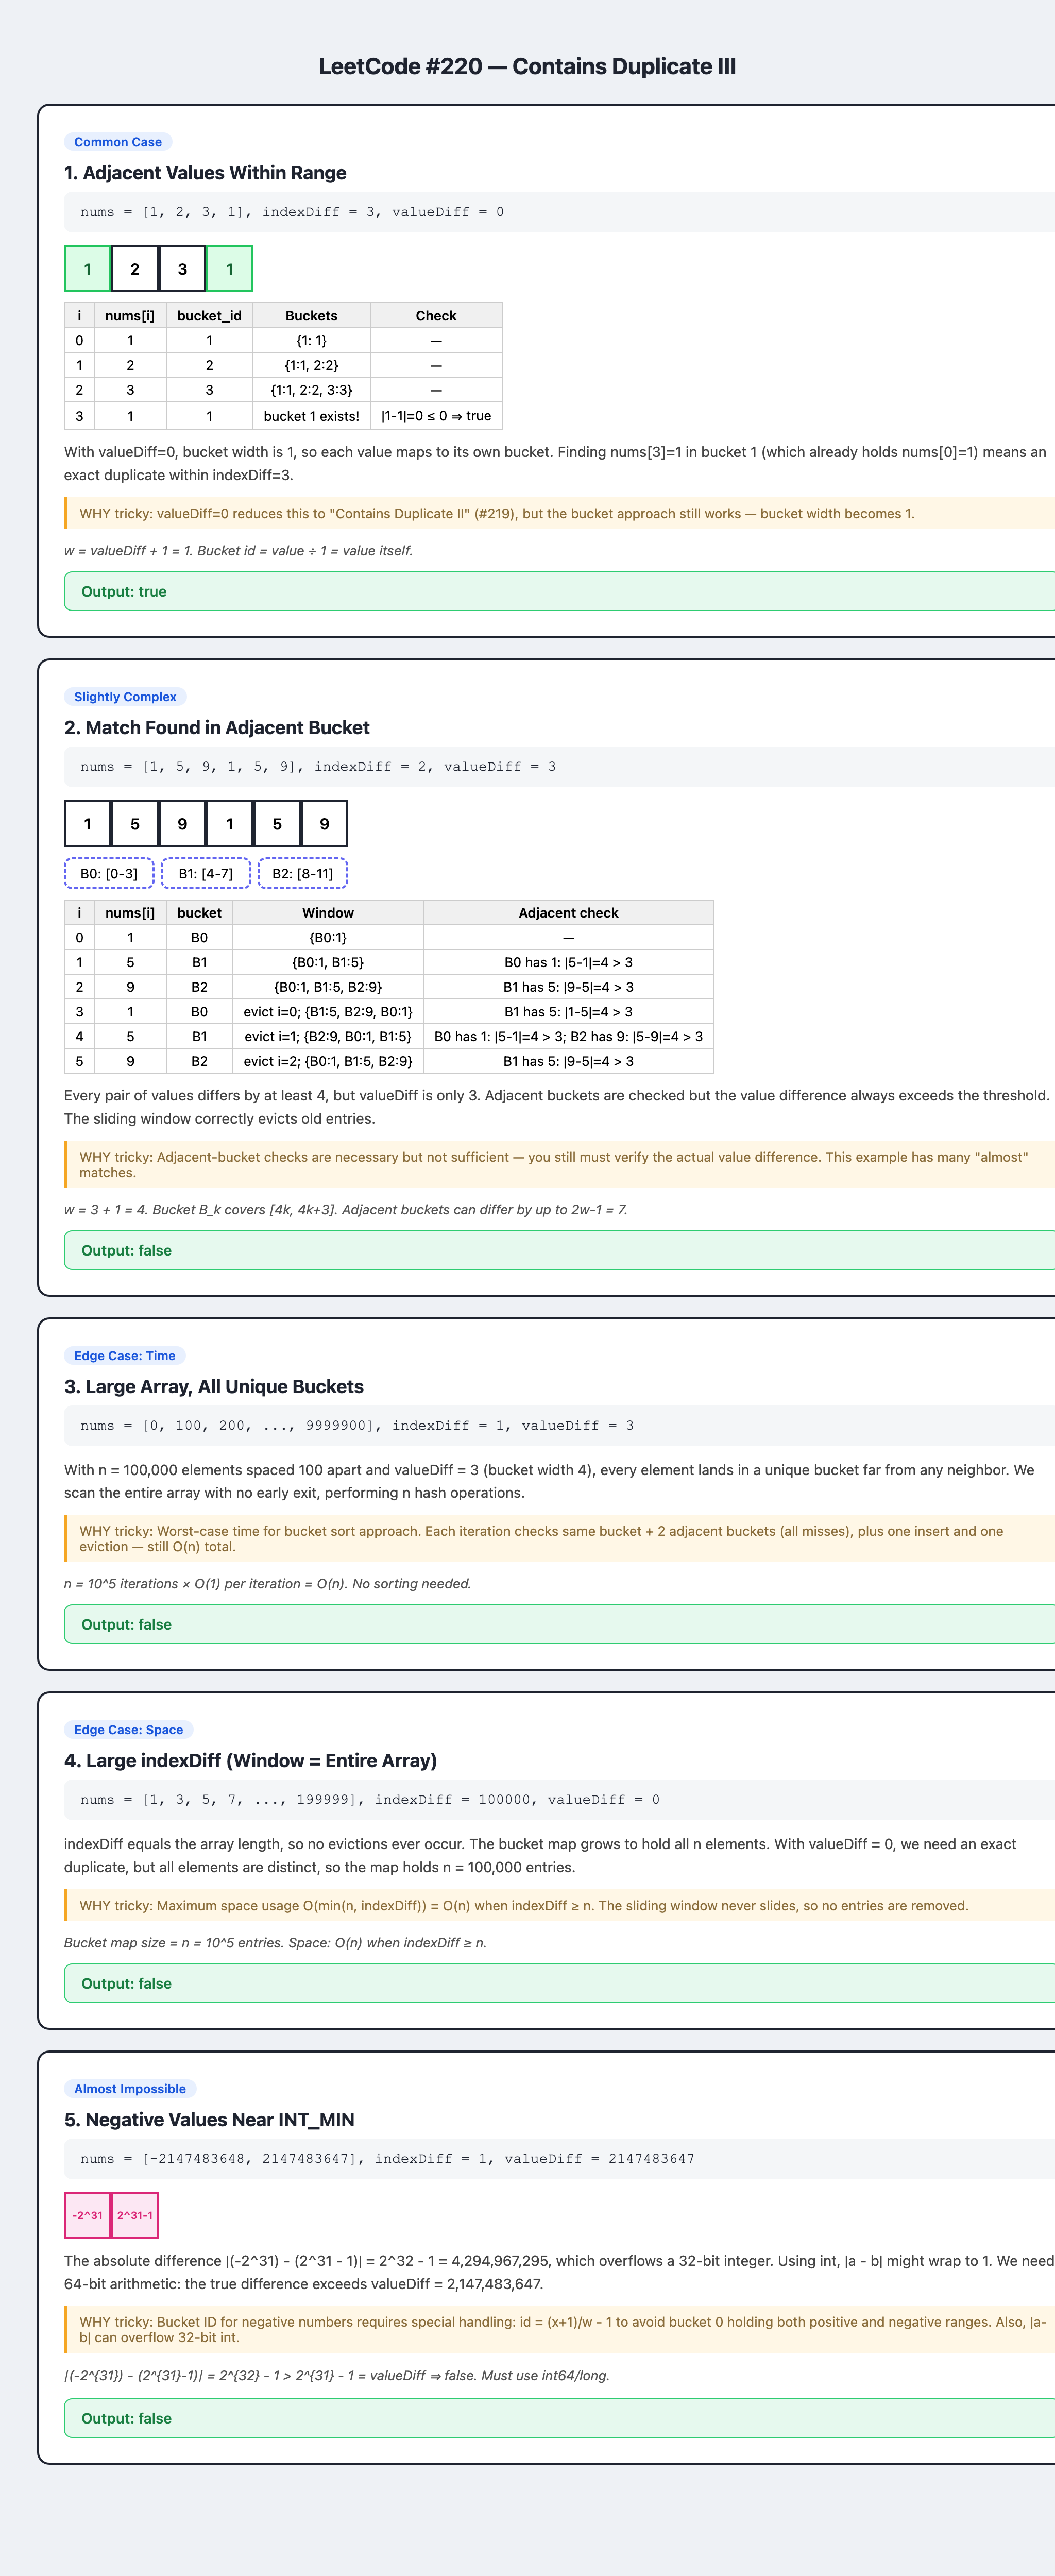